In [1]:
import tensorflow_datasets as tfds
import tensorflow as tf

ds, info = tfds.load('cifar10', with_info=True)
train_ds = ds['train']
test_ds = ds['test']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.VH92IO_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.VH92IO_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


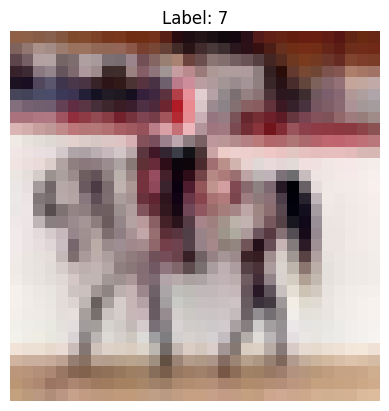

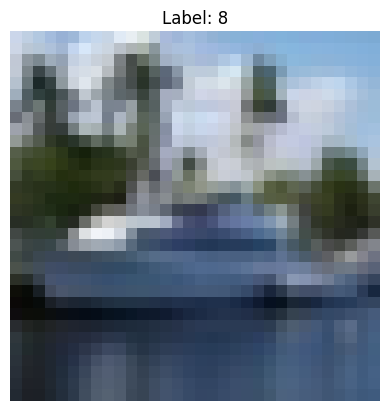

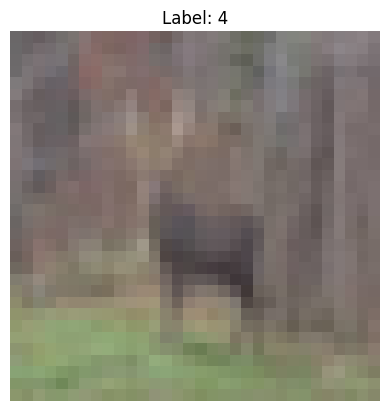

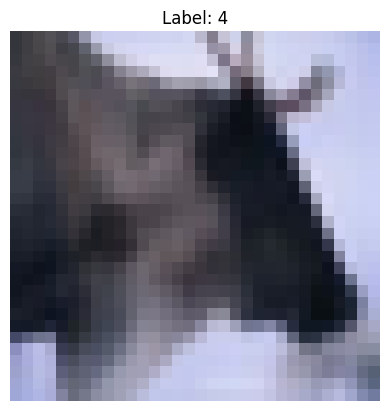

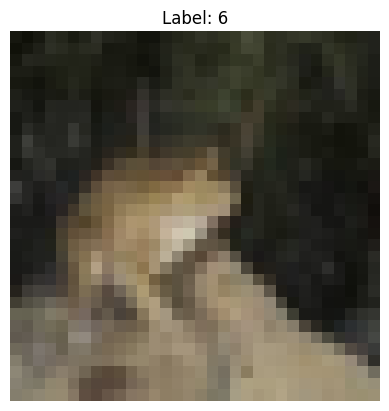

In [2]:
import matplotlib.pyplot as plt

for example in train_ds.take(5):
  image, label = example['image'], example['label']
  plt.figure()
  plt.imshow(image)
  plt.title(f"Label: {label.numpy()}")
  plt.axis("off")
  plt.show()

In [3]:
def preprocess_squash(features):
  image = tf.cast(features['image'], tf.float32) / 255.0
  mean = tf.constant([0.485, 0.456, 0.406])
  std = tf.constant([0.229, 0.224, 0.225])
  image = (image - mean) / std
  image = tf.reshape(image, (32*32*3,))
  label = features['label']
  return image, label

def preprocess(features):
  image = tf.cast(features['image'], tf.float32) / 255.0
  mean = tf.constant([0.485, 0.456, 0.406])
  std = tf.constant([0.229, 0.224, 0.225])
  image = (image - mean) / std
  label = features['label']
  return image, label

In [4]:
train_ds_f = train_ds.map(preprocess_squash).shuffle(10000).batch(64)
test_ds_f = test_ds.map(preprocess_squash).batch(64)

## Dimensionality Crisis (FFN)

Let's first use a feedforward network to classify the images.

In [7]:
ffn = tf.keras.Sequential([
  tf.keras.layers.Dense(512, activation='relu'),
  tf.keras.layers.Dense(512, activation='relu'),
  tf.keras.layers.Dense(10, 'softmax')
])

ffn.compile(optimizer='nadam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [11]:
ffn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,523,489 (21.07 MB)

 Trainable params: 1,841,162 (7.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,682,327 (14.05 MB)

In [9]:
input_size = 32 * 32 * 3
l1_size = 512
l2_size = 512
l3_size = 512
output_size = 10

l1_weights = input_size * l1_size
l1_biases = l1_size
l2_weights = l1_size * l2_size
l2_biases = l2_size
output_weights = l2_size * output_size
output_biases = output_size

total_params = l1_weights + l1_biases + l2_weights + l2_biases + output_weights + output_biases
print(f'Total Number of Trainable paramaters is: {total_params}')

Total Number of Trainable paramaters is: 1841162


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.4068 - loss: 1.7071 - val_accuracy: 0.4579 - val_loss: 1.5542
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.4816 - loss: 1.4708 - val_accuracy: 0.4724 - val_loss: 1.4985
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 39ms/step - accuracy: 0.5180 - loss: 1.3656 - val_accuracy: 0.5000 - val_loss: 1.4423
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.5442 - loss: 1.2848 - val_accuracy: 0.5146 - val_loss: 1.4166
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 50ms/step - accuracy: 0.5704 - loss: 1.2161 - val_accuracy: 0.5035 - val_loss: 1.4698
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5035 - loss: 1.4698


Test accuracy: 0.5034999847412109


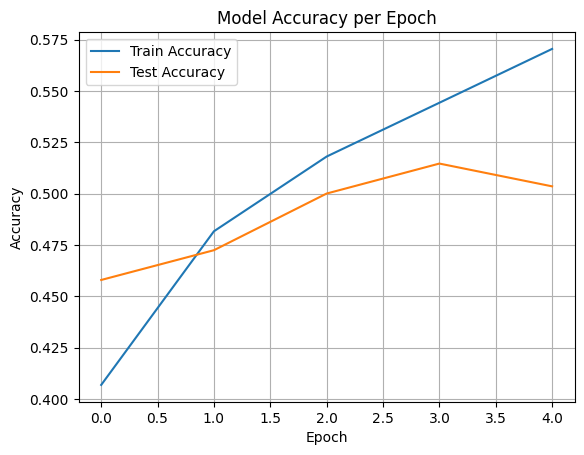

In [10]:
def plot_accuracy(history):
    plt.plot(history.history['accuracy'], label='Train Accuracy')

    plt.plot(history.history['val_accuracy'], label='Test Accuracy')

    plt.title('Model Accuracy per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


history = ffn.fit(train_ds_f, epochs=5, validation_data=test_ds_f)

test_loss, test_acc = ffn.evaluate(test_ds_f)
print("\n\nTest accuracy:", test_acc)
plot_accuracy(history)

Now we test the prediction confidence on one image

Original prediction: 6 True label: 6 Confidence: 0.9105284
Shifted prediction: 3 True label: 6 Confidence: 0.33301276


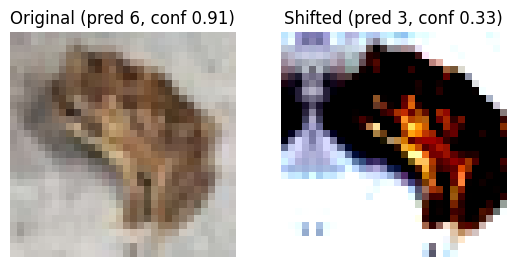

(np.float32(0.9105284), np.float32(0.33301276), np.True_, np.False_)

In [ ]:
import numpy as np

def test_prediction(model, dataset, idx=0, squash=False, plot=True, shift_pixels=4):
  for example in dataset.skip(idx).take(1):
    image = tf.cast(example['image'], tf.float32) / 255.0
    true_label = example['label'].numpy()
    mean = tf.constant([0.485, 0.456, 0.406])
    std = tf.constant([0.229, 0.224, 0.225])
    image_norm = (image - mean) / std

    if squash:
      original = tf.reshape(image_norm, (1, 32*32*3))
    else:
      original = tf.expand_dims(image_norm, axis=0)

    probs_original = model.predict(original, verbose=0)
    conf_original = np.max(probs_original)
    pred_original = np.argmax(probs_original)

    shifted_img_cropped = tf.pad(image_norm, [[0,0],[shift_pixels,0],[0,0]], mode="REFLECT")
    shifted_img_cropped = tf.image.crop_to_bounding_box(shifted_img_cropped, 0, 0, 32, 32)

    if squash:
      shifted = tf.reshape(shifted_img_cropped, (1, 32*32*3))
    else:
      shifted = tf.expand_dims(shifted_img_cropped, axis=0)

    probs_shifted = model.predict(shifted, verbose=0)
    conf_shifted = np.max(probs_shifted)
    pred_shifted = np.argmax(probs_shifted)

    if plot:
      print("Original prediction:", pred_original,
            "True label:", true_label,
            "Confidence:", conf_original)
      print("Shifted prediction:", pred_shifted,
            "True label:", true_label,
            "Confidence:", conf_shifted)

      plt.subplot(1,2,1)
      if squash:
        plt.imshow(tf.reshape(image, (32,32,3)))
      else:
        plt.imshow(original[0])
      plt.title(f"Original (pred {pred_original}, conf {conf_original:.2f})")
      plt.axis("off")

      plt.subplot(1,2,2)
      if squash:
        plt.imshow(tf.reshape(shifted, (32,32,3)))
      else:
        plt.imshow(shifted[0])
      plt.title(f"Shifted (pred {pred_shifted}, conf {conf_shifted:.2f})")
      plt.axis("off")

      plt.show()

    return conf_original, conf_shifted, pred_original == true_label, pred_shifted == true_label

test_prediction(ffn, test_ds, np.random.randint(0, len(test_ds)), squash=True)

Testing on 100 examples in the validation set

In [ ]:
avg_conf = 0
avg_conf_shifted = 0
n = 0

for i in range(100):
  c, c_s, correct, correct_s = test_prediction(ffn, test_ds, i, squash=True, plot=False)

  if correct:
    if not correct_s:
      c_s = 0
    avg_conf += c
    avg_conf_shifted += c_s
    n += 1

print(f"Average Confidence: {avg_conf/n:.2f} | After Shift: {avg_conf_shifted/n:.2f}")

Average Confidence: 0.70 | After Shift: 0.48


## The CNN Baseline

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.3912 - loss: 1.6032 - val_accuracy: 0.5134 - val_loss: 1.3297
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5482 - loss: 1.2335 - val_accuracy: 0.5468 - val_loss: 1.2994
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6102 - loss: 1.0761 - val_accuracy: 0.5562 - val_loss: 1.2727
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.6506 - loss: 0.9755 - val_accuracy: 0.6322 - val_loss: 1.0527
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.6801 - loss: 0.8978 - val_accuracy: 0.6631 - val_loss: 0.9528
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.7034 - loss: 0.8349 - val_accuracy: 0.6810 - val_loss: 0.9479
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.7219 - loss: 0.7833 - val_accuracy: 0.6909 - val_loss: 0.8758
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7400 - loss: 0.7399 - 

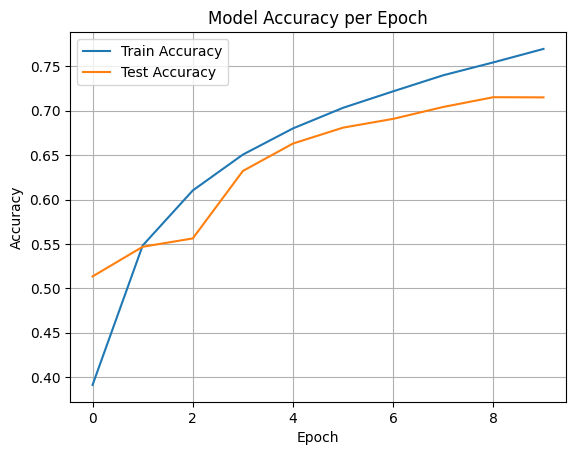

In [ ]:
train_ds_c = train_ds.map(preprocess).shuffle(10000).batch(64)
test_ds_c = test_ds.map(preprocess).batch(64)

cnn = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), (1, 1), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(64, (3, 3), (1, 1), activation='relu'),
    tf.keras.layers.Conv2D(128, (3, 3), (1, 1), activation='relu'),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(10, 'softmax')
])

cnn.compile(optimizer='nadam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = cnn.fit(train_ds_c, epochs=10, validation_data=test_ds_c)
test_loss, test_acc = cnn.evaluate(test_ds_c)
print("\n\nTest accuracy:", test_acc)
plot_accuracy(history)

Original prediction: 7 True label: 7 Confidence: 0.86897695
Shifted prediction: 7 True label: 7 Confidence: 0.8610961


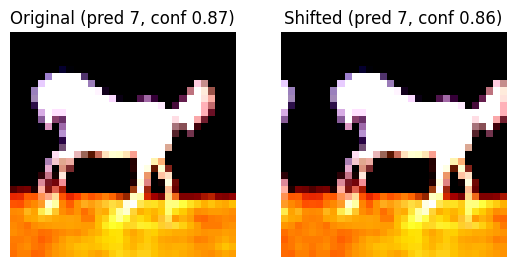

(np.float32(0.86897695), np.float32(0.8610961), np.True_, np.True_)

In [ ]:
test_prediction(cnn, test_ds, np.random.randint(0, len(test_ds)))

In [ ]:
avg_conf = 0
avg_conf_shifted = 0
n = 0

for i in range(100):
  c, c_s, correct, correct_s = test_prediction(cnn, test_ds, i, plot=False)

  if correct:
    if not correct_s:
      c_s = 0
    avg_conf += c
    avg_conf_shifted += c_s
    n += 1

print(f"Average Confidence: {avg_conf/n:.2f} | After Shift: {avg_conf_shifted/n:.2f}")

Average Confidence: 0.83 | After Shift: 0.79


### Transfer Learning to a ResNET-18 Model

In [ ]:
%pip install keras-hub
import keras_hub

In [ ]:
def preprocess_rn(features):
  image = tf.cast(features['image'], tf.float32) / 255.0

  mean = tf.constant([0.485, 0.456, 0.406])
  std = tf.constant([0.229, 0.224, 0.225])
  image = (image - mean) / std

  label = features['label']
  return image, label

train_ds_r = train_ds.map(preprocess_rn).shuffle(10000).batch(64)
test_ds_r = test_ds.map(preprocess_rn).batch(64)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.5120 - loss: 1.4062 - val_accuracy: 0.6888 - val_loss: 0.8902
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.7329 - loss: 0.7760 - val_accuracy: 0.7551 - val_loss: 0.7108
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.7989 - loss: 0.5816 - val_accuracy: 0.7880 - val_loss: 0.6246
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.8411 - loss: 0.4600 - val_accuracy: 0.8037 - val_loss: 0.6008
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.8726 - loss: 0.3662 - val_accuracy: 0.8111 - val_loss: 0.5934
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.8970 - loss: 0.2946 - val_accuracy: 0.8137 - val_loss: 0.6140
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9204 - loss: 0.2297 - val_accuracy: 0.8169 - val_loss: 0.6395
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9368 - loss: 0.1808 - 

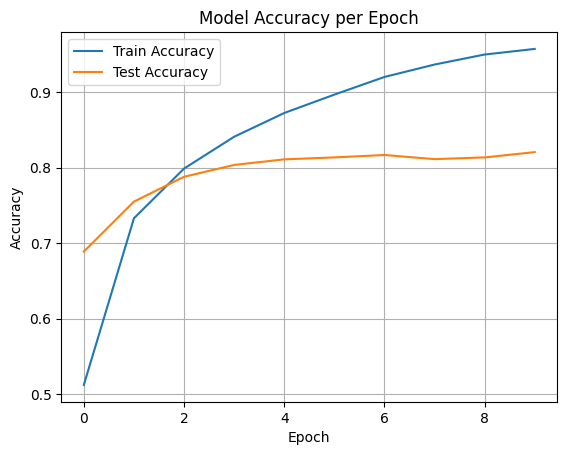

In [ ]:
tf.keras.backend.clear_session()
backbone = keras_hub.models.ResNetBackbone.from_preset("resnet_18_imagenet", include_top=False)

inputs = tf.keras.Input(shape=(32, 32, 3))
layer = backbone(inputs)
layer = tf.keras.layers.GlobalAveragePooling2D()(layer)
layer = tf.keras.layers.Dense(10, activation="softmax")(layer)
resnet = tf.keras.Model(inputs=inputs, outputs=layer)

resnet.compile(
    optimizer=tf.keras.optimizers.Nadam(4e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history = resnet.fit(train_ds_r, epochs=10, validation_data=test_ds_r)

test_loss, test_acc = resnet.evaluate(test_ds_r)
print("\n\nTest accuracy after fine-tuning:", test_acc)
plot_accuracy(history)

Base CNN has accuracy of 66% while ResNET-18 has accuracy of 82%

In [ ]:
avg_conf = 0
avg_conf_shifted = 0
n = 0

for i in range(100):
  c, c_s, correct, correct_s = test_prediction(resnet, test_ds, i, plot=False)

  if correct:
    if not correct_s:
      c_s = 0
    avg_conf += c
    avg_conf_shifted += c_s
    n += 1

print(f"Average Confidence: {avg_conf/n:.2f} | After Shift: {avg_conf_shifted/n:.2f}")

Average Confidence: 0.94 | After Shift: 0.83


## MobileNet & Efficiency

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_separable_conv.py:104: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 32ms/step - accuracy: 0.2868 - loss: 1.8269 - val_accuracy: 0.3573 - val_loss: 1.6542
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.3766 - loss: 1.6062 - val_accuracy: 0.4188 - val_loss: 1.5018
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.4423 - loss: 1.4698 - val_accuracy: 0.4588 - val_loss: 1.4458
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4946 - loss: 1.3577 - val_accuracy: 0.4729 - val_loss: 1.4341
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5282 - loss: 1.2859 - val_accuracy: 0.5386 - val_loss: 1.2637
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.5489 - loss: 1.2363 - val_accuracy: 0.5524 - val_loss: 1.2323
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.5663 - loss: 1.1900 - val_accuracy: 0.5631 - val_loss: 1.2202
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.5800 - loss: 1.1550 - val_accuracy: 0.574

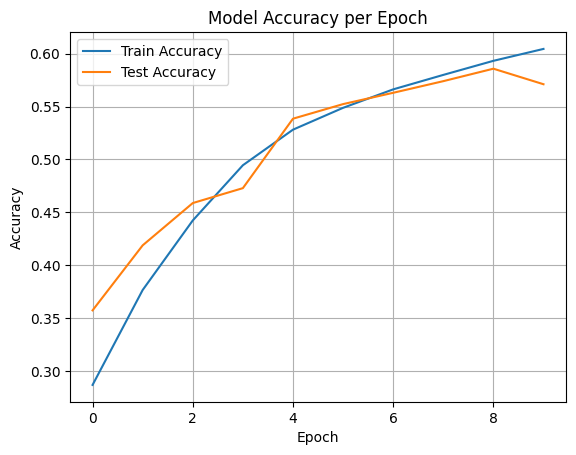

In [ ]:
mobile_cnn = tf.keras.Sequential([
    tf.keras.layers.SeparableConv2D(32, (3, 3), strides=(1, 1), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.SeparableConv2D(64, (3, 3), strides=(1, 1), activation='relu'),
    tf.keras.layers.SeparableConv2D(128, (3, 3), strides=(1, 1), activation='relu'),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

mobile_cnn.compile(optimizer='nadam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = mobile_cnn.fit(train_ds_c, epochs=10, validation_data=test_ds_c)
test_loss, test_acc = mobile_cnn.evaluate(test_ds_c)
print("\n\nTest accuracy:", test_acc)
plot_accuracy(history)

In [ ]:
avg_conf = 0
avg_conf_shifted = 0
n = 0

for i in range(100):
  c, c_s, correct, correct_s = test_prediction(mobile_cnn, test_ds, i, plot=False)

  if correct:
    if not correct_s:
      c_s = 0
    avg_conf += c
    avg_conf_shifted += c_s
    n += 1

print(f"Average Confidence: {avg_conf/n:.2f} | After Shift: {avg_conf_shifted/n:.2f}")

Average Confidence: 0.73 | After Shift: 0.68


For CNN

In [ ]:
cnn_l1 = (3 * 3 * 3) * 32 + 32
cnn_l2 = (3 * 3 * 32) * 64 + 64
cnn_l3 = (3 * 3 * 64) * 128 + 128

cnn_total = cnn_l1 + cnn_l2 + cnn_l3
cnn_total

93248

For DepthWiseSeperable Conv Layers

In [ ]:
dws_l1 = (3 * 3 * 3 + 3) + (3 * 32 + 32)
dws_l2 = (3 * 3 * 32 + 32) + (32 * 64 + 64)
dws_l3 = (3 * 3 * 64 + 64) + (64 * 128 + 128)

dws_total = dws_l1 + dws_l2 + dws_l3
dws_total

11550

In [ ]:
print(f"Percentage Reduction in Convolution Parameters is {100 * (cnn_total - dws_total) / cnn_total:.2f}%")

Percentage Reduction in Convolution Parameters is 87.61%


### Comparison with standard CNN

In [ ]:
cnn.save('cnn.keras')
mobile_cnn.save('mobile_cnn.keras')

In [ ]:
import os

print("CNN size:", os.path.getsize("cnn.keras") / (1024**2), "MB")
print("Mobile CNN size:", os.path.getsize("mobile_cnn.keras") / (1024**2), "MB")

CNN size: 20.7058162689209 MB
Mobile CNN size: 19.77337074279785 MB


## Detection Sprint
# Blood Cell Count Detection

In [ ]:
ds, info = tfds.load('bccd', with_info=True)
b_train_ds = ds['train']
b_test_ds = ds['test']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/bccd/incomplete.Z6OQHN_1.0.0/bccd-validation.tfrecord*...:   0%|          …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/bccd/incomplete.Z6OQHN_1.0.0/bccd-test.tfrecord*...:   0%|          | 0/72…

Dataset bccd downloaded and prepared to /root/tensorflow_datasets/bccd/1.0.0. Subsequent calls will reuse this data.


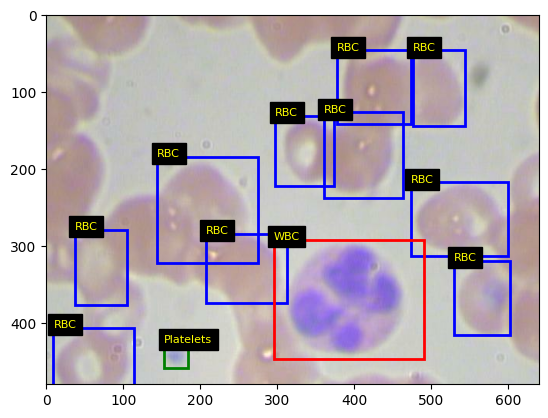

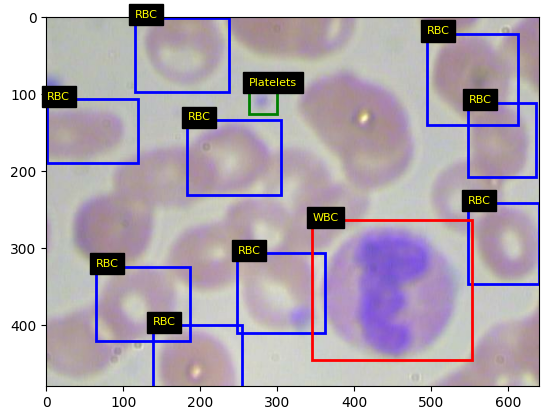

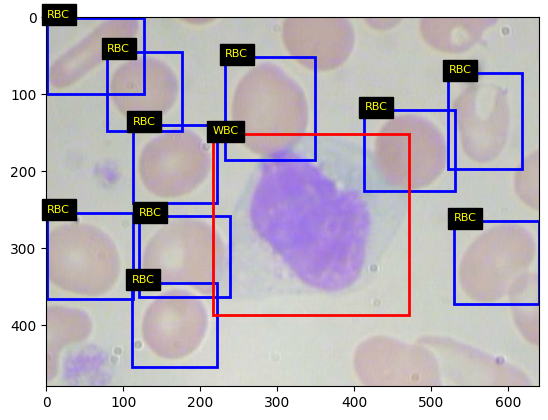

In [ ]:
import matplotlib.patches as patches

labels = info.features['objects']['label'].names

def plot_example(example):
    image = example['image']
    bboxes = example['objects']['bbox']
    classes = example['objects']['label']

    img = image.numpy()

    fig, ax = plt.subplots(1)
    ax.imshow(img)

    for bbox, cls in zip(bboxes, classes):
        ymin, xmin, ymax, xmax = bbox.numpy()
        rect = patches.Rectangle(
            (xmin * img.shape[1], ymin * img.shape[0]),
            (xmax - xmin) * img.shape[1],
            (ymax - ymin) * img.shape[0],
            linewidth=2,
            edgecolor='red' if labels[cls] == 'WBC' else 'blue' if labels[cls] == 'RBC' else 'green',
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(xmin * img.shape[1], ymin * img.shape[0], labels[cls],
                color='yellow', fontsize=8, backgroundcolor='black')

    plt.show()


for example in b_train_ds.take(3):
    plot_example(example)

In [ ]:
labels = info.features['objects']['label'].names
print(labels)

['RBC', 'WBC', 'Platelets']


In [ ]:
def preprocess_det(features):
  image = tf.cast(features['image'], tf.float32) / 255.0
  image = tf.image.resize(image, (96, 96))

  mean = tf.constant([0.485, 0.456, 0.406])
  std = tf.constant([0.229, 0.224, 0.225])
  image = (image - mean) / std

  label = features['objects']['label']
  bboxes = example['objects']['bbox']
  return image, label, bboxes

b_train_ds_r = b_train_ds.map(preprocess_det).shuffle(100).batch(32)
b_test_ds_r = b_test_ds.map(preprocess_det).batch(32)

In [ ]:
inputs = tf.keras.Input(shape=(96,96,3))

layer = tf.keras.layers.SeparableConv2D(32, (3,3), strides=(1,1), activation='relu')(inputs)
layer = tf.keras.layers.SeparableConv2D(64, (3,3), strides=(1,1), activation='relu')(layer)
layer = tf.keras.layers.SeparableConv2D(128, (3,3), strides=(1,1), activation='relu')(layer)

layer = tf.keras.layers.GlobalAveragePooling2D()(layer)
layer = tf.keras.layers.Flatten()(layer)
layer = tf.keras.layers.Dense(1024, activation='relu')(layer)
layer = tf.keras.layers.Dense(1024, activation='relu')(layer)
layer = tf.keras.layers.Dropout(0.3)(layer)
layer = tf.keras.layers.Dense(512, activation='relu')(layer)

class_output = tf.keras.layers.Dense(3, activation='softmax', name="class_output")(layer)

bbox_output = tf.keras.layers.Dense(4, activation='sigmoid', name="bbox_output")(layer)

mobile_cnn2 = tf.keras.Model(inputs=inputs, outputs=[class_output, bbox_output])
